In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/5week/breast_cancer.csv", index_col=0)
df.head
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


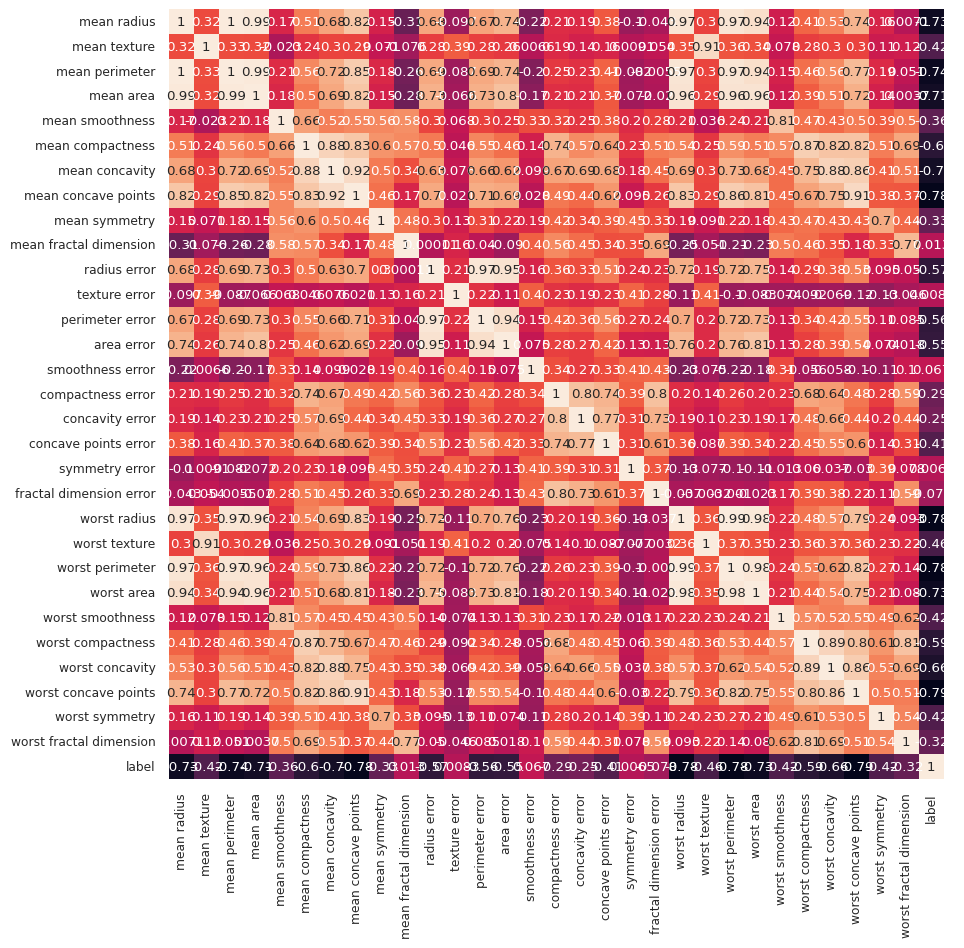

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음

df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

In [ ]:
selected_features = [
    'mean concave points',   # 타겟 상관 1위
    'area error',            # 측정 오차
    'mean concavity',        # 오목도
    'mean compactness',      # 밀도
    'mean texture',          # 질감
    'mean fractal dimension',# 경계 복잡도
]
X = df[selected_features].values

In [ ]:
y = df['mean area']
y.head()

,mean area
0,1001.0
1,1326.0
2,1203.0
3,386.1
4,1297.0


In [ ]:
X

array([[1.471e-01, 1.534e+02, 3.001e-01, 2.776e-01, 1.038e+01, 7.871e-02],
       [7.017e-02, 7.408e+01, 8.690e-02, 7.864e-02, 1.777e+01, 5.667e-02],
       [1.279e-01, 9.403e+01, 1.974e-01, 1.599e-01, 2.125e+01, 5.999e-02],
       ...,
       [5.302e-02, 4.855e+01, 9.251e-02, 1.023e-01, 2.808e+01, 5.648e-02],
       [1.520e-01, 8.622e+01, 3.514e-01, 2.770e-01, 2.933e+01, 7.016e-02],
       [0.000e+00, 1.915e+01, 0.000e+00, 4.362e-02, 2.454e+01, 5.884e-02]])

In [ ]:
y

,mean area
0,1001.0
1,1326.0
2,1203.0
3,386.1
4,1297.0
...,...
564,1479.0
565,1261.0
566,858.1
567,1265.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((455, 6), (455,), (114, 6), (114,))

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

In [ ]:
from keras.models import Sequential
from keras.optimizers import SGD,Adam
from keras.layers import Dense, Input, Dropout

model = Sequential()

model.add(Input(shape=(6,)))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
N_EPOCHS = 30

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.5752 - mse: 0.5752 - val_loss: 0.1402 - val_mse: 0.1402
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2522 - mse: 0.2522 - val_loss: 0.0896 - val_mse: 0.0896
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2150 - mse: 0.2150 - val_loss: 0.0875 - val_mse: 0.0875
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1902 - mse: 0.1902 - val_loss: 0.0813 - val_mse: 0.0813
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2055 - mse: 0.2055 - val_loss: 0.0791 - val_mse: 0.0791
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1819 - mse: 0.1819 - val_loss: 0.0814 - val_mse: 0.0814
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1536 - mse: 0.1536 - val_loss: 0.0761 - val_mse: 0.0761
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1391 - mse: 0.1391 - val_loss: 0.0865 - val_mse: 0.0865
Epoch 9/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.129

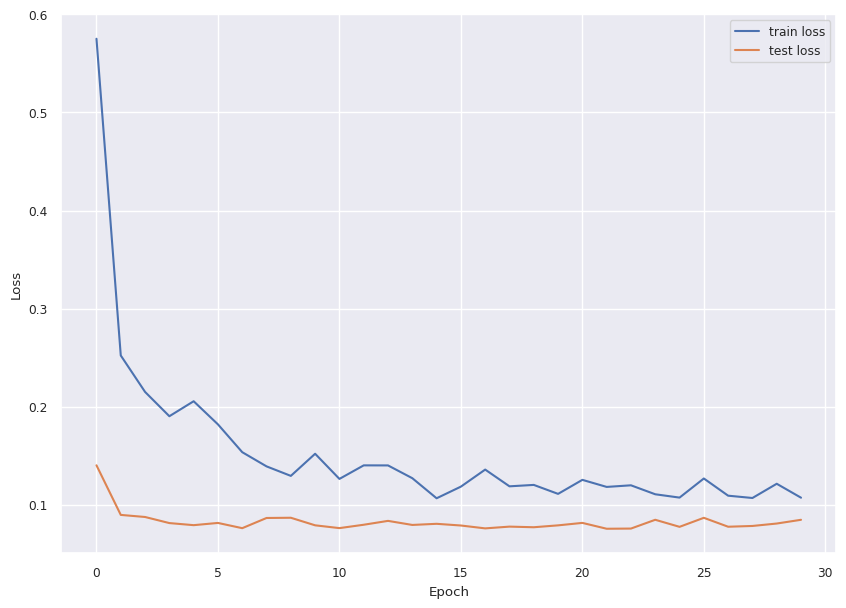

In [ ]:
# loss 그래프
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0846 - mse: 0.0846


[0.08460575342178345, 0.08460575342178345]

In [ ]:
# 실제 RMSE
import numpy as np
y_pred_orig = scaler_y.inverse_transform(y_pred)
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1))
print("RMSE:", np.sqrt(np.mean((y_pred_orig - y_test_orig)**2)))

RMSE: 103.1290567293862


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


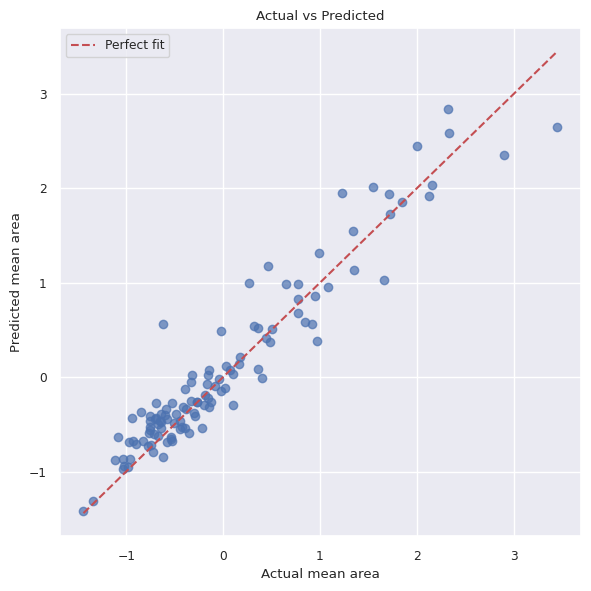

In [ ]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_test).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Perfect fit')
plt.xlabel('Actual mean area')
plt.ylabel('Predicted mean area')
plt.title('Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()